In [1]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
def load_datasets(path):
    dataset = QSPRDataset.fromTableFile(
    filename=path,
    store_dir="dataset_outputs/A2AR/data",
    name="A2ARDataset",
    target_props=[{"name": "Y", "task": "SINGLECLASS", "th": [0.5]}],
    random_state=42,
    smiles_col = 'Drug',
    sep=','
    )
    return dataset
    

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X1_all = load_datasets("A2AR/data/a2ar_train_1")

X2_all = load_datasets("A2AR/data/a2ar_val_1")

X3_all = load_datasets("A2AR/data/a2ar_test_1")


In [4]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

class Dataset_creator():
    def __init__(self, model_names=['RoBERTa_ZINC'], corr_thrsh= 0.95):
        self.variance = VarianceThreshold(threshold=0.0)
        self.model_names = model_names
        self.corr_thrsh = corr_thrsh
        self.selected_indices = None
        
    def fit_transform(self, dataset):
        dataset.prepareDataset(feature_calculators=[MorganFP(radius=2, nBits=1024)], recalculate_features=True, shuffle=False)
        rdkit_descs = RDKitDescs()
        dataset.addDescriptors([rdkit_descs])
        display(dataset.X.shape)
        
        dataset.descriptorSets
        dataset_embs = self.create_embs(dataset)
        dataset_embs.index = dataset.X.index
        dataset.X = pd.concat([dataset.X, dataset_embs], axis=1)
        display(dataset.X.shape)
        
        dataset_no_var_np = self.variance.fit_transform(dataset.X)
        mask = self.variance.get_support()
        dataset_without_no_var = pd.DataFrame(
            dataset_no_var_np,
            columns=dataset.X.columns[mask],
            index=dataset.X.index)
        display(dataset_without_no_var.shape)

        
        dataset_without_high_corr = self.high_correlation(dataset_without_no_var)
        display(dataset_without_high_corr.shape)
        
        dataset.X = dataset_without_high_corr
        return dataset
        
    def transform(self, dataset):
        dataset.prepareDataset(feature_calculators=[MorganFP(radius=2, nBits=1024)], recalculate_features=True, shuffle=False)
        rdkit_descs = RDKitDescs()
        dataset.addDescriptors([rdkit_descs])
        display(dataset.X.shape)

        dataset.descriptorSets
        dataset_embs = self.create_embs(dataset)
        dataset_embs.index = dataset.X.index
        dataset.X = pd.concat([dataset.X, dataset_embs], axis=1)
        display(dataset.X.shape)

        dataset_no_var_np = self.variance.transform(dataset.X)
        mask = self.variance.get_support()
        dataset_without_no_var = pd.DataFrame(
            dataset_no_var_np,
            columns=dataset.X.columns[mask],
            index=dataset.X.index)
        display(dataset_without_no_var.shape)

        dataset_without_high_corr = dataset_without_no_var[self.selected_indices]
        display(dataset_without_high_corr.shape)

        dataset.X = dataset_without_high_corr
        return dataset

    def high_correlation(self, df: pd.DataFrame):
        corr_matrix = df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        to_drop = [column for column in upper.columns if any(upper[column] > self.corr_thrsh)]
        self.selected_indices = df.columns.difference(to_drop)
        
        return df[self.selected_indices]

        
    def create_embs(self, dataset):
        dataset.df["SMILES"] = dataset.df["Drug"]
        final_emb = pd.DataFrame()
        for model_name in self.model_names:
            extractor = MolEmb.EmbeddingExtractor(model_name=model_name, df=dataset.df)
            new_emb, dataset.df = extractor.get_embeddings()
            display(type(new_emb))
            if final_emb.empty:
                final_emb = new_emb
            else:
                final_emb = pd.concat([final_emb, new_emb], axis=1)
        final_emb.columns = final_emb.columns.astype(str)
        display(final_emb)
        return final_emb
    


In [5]:
cls = Dataset_creator(['Mol2Vec', 'RoBERTa_ZINC'])

In [ ]:
X1_all = cls.fit_transform(X1_all)
X2_all = cls.transform(X2_all)
X3_all = cls.transform(X3_all)

In [ ]:
X1 = X1_all.X
y1 = X1_all.y
X2 = X2_all.X
y2 = X2_all.y
X3 = X3_all.X
y3 = X3_all.y

In [2]:
X1 = pd.read_csv("A2AR/mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("A2AR/mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("A2AR/mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("A2AR/mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("A2AR/mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("A2AR/mod_data/y3.1", index_col="QSPRID")

In [3]:
y1.sum()/y1.count()

Y    0.962609
dtype: float64

In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.75, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,1618,1619,1620,1621,1622,1623,1624,1625,1626,1627
0,0.629350,0.409822,0.114763,0.849649,-1.302256,-1.582738,-0.678928,-1.233195,-1.434335,-1.134524,...,-0.020387,-0.116076,-0.184214,-0.057747,-0.133263,-0.310778,-0.239901,-0.195451,-0.279983,1.233341
1,1.225274,0.942670,-0.168389,-0.169440,-0.341978,-0.052202,2.212653,0.803415,0.814574,0.266891,...,-0.020387,-0.116076,-0.184214,-0.057747,-0.133263,-0.310778,-0.239901,4.974340,-0.279983,-1.882446
2,-0.982475,0.726753,-1.033329,1.253848,-0.652347,0.063208,0.950025,-0.664100,-1.904197,-1.753757,...,-0.020387,-0.116076,-0.184214,-0.057747,-0.133263,-0.310778,-0.239901,-0.195451,-0.279983,2.249445
3,1.324123,1.301264,0.499300,-2.170308,-0.573437,-1.556576,0.760613,0.555091,-0.346715,-0.279360,...,-0.020387,-0.116076,-0.184214,-0.057747,-0.133263,-0.310778,-0.239901,2.389444,-0.279983,-1.263797
4,0.402699,0.209699,0.333955,1.363094,-1.035884,-1.581501,-0.340915,-0.499982,-1.004890,-1.360252,...,-0.020387,-0.116076,-0.184214,-0.057747,-0.133263,-0.310778,-0.239901,-0.195451,-0.279983,1.151519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4049,1.891771,0.360576,0.477964,-1.354515,-0.732708,0.171503,1.183780,0.179994,0.303568,0.490963,...,-0.020387,-0.116076,-0.184214,-0.057747,-0.133263,-0.310778,-0.239901,-0.195451,-0.279983,-0.114654
4050,0.716711,0.865579,-0.507108,-0.750754,1.744370,0.565608,0.490784,-0.797940,0.755068,-1.654602,...,-0.020387,-0.116076,-0.184214,-0.057747,-0.133263,-0.310778,-0.239901,-0.195451,-0.279983,-0.093326
4051,1.975479,0.117300,0.092659,-0.489177,-0.268876,-0.309958,0.820500,1.908886,-0.705008,2.752966,...,-0.020387,-0.116076,-0.184214,-0.057747,-0.133263,-0.310778,-0.239901,-0.195451,-0.279983,0.918278
4052,-0.545329,-0.348805,-0.012472,-0.165231,0.250409,-1.122110,-1.049582,0.434504,1.112915,-0.532988,...,-0.020387,-0.116076,-0.184214,-0.057747,-0.133263,-0.310778,-0.239901,-0.195451,-0.279983,-0.712181


In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=411)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [7]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [8]:
n_components

1

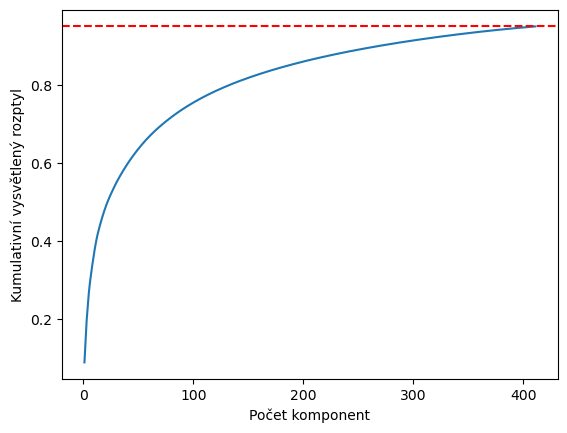

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [10]:
y1.sum()/y1.count()

Y    0.571534
dtype: float64

In [11]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [12]:
from sklearn.model_selection import ParameterGrid
from torch.nn import functional as F
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, matthews_corrcoef
import pandas as pd

def test_fun(dic,  X_train, y_train, X_test, y_test) -> pd.DataFrame:
    param_grid_t = ParameterGrid(dic)
    i = 0
    val_f1_t = []
    val_acc_t = []
    val_mcc_t = []
    param_len_t = len(param_grid_t)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device used:", device)
    for param in param_grid_t:
        i += 1
        print(i, '/', param_len_t)
        model_sts_t = STFullyConnected(n_dim=X_train.shape[1],  # počet vstupních neuronů (počet deskriptorů)
        n_class=1,  # regresní úloha (1 výstup)
        gpus=[],
        device=device,
        is_reg=False, **param)
        model_sts_t.fit(X_train, y_train)
        res = model_sts_t.predict(X_test)
        res = res >0.5
        val_f1_t.append(f1_score(res, y_test))
        val_acc_t.append(accuracy_score(res, y_test))
        val_mcc_t.append(matthews_corrcoef(res, y_test))
        print(param)
        print(f1_score(res, y_test))
        print(accuracy_score(res, y_test))
        print(matthews_corrcoef(res, y_test))
    my_df = pd.DataFrame(param_grid_t)
    my_df["F1"] = val_f1_t
    my_df["Acc"] = val_acc_t
    my_df["MCC"] = val_mcc_t
    return my_df

In [13]:
import optuna
from sklearn.metrics import f1_score, accuracy_score, matthews_corrcoef
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
def objective(trial, X_train, y_train, X_test, y_test):
    dropout_frac = trial.suggest_categorical("dropout_frac", [0, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9])
    patience = trial.suggest_categorical("patience", [10, 40, 75])
    tol = trial.suggest_categorical("tol", [1e-5, 1e-4, 1e-3, 1e-2, 0])
    weight_decay = trial.suggest_categorical("weight_decay", [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 0])
    n_epochs = trial.suggest_categorical("n_epochs", [200, 300, 500, 1000])
    batch_size = trial.suggest_categorical("batch_size", [1024, 512, 256, 128, 64])
    optimizer = trial.suggest_categorical("optimizer", ["optim.AdamW", "optim.RMSprop"])
    lr = trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6])
    neuron_layers_dict = {
    '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
    '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]': [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
    '[4096, 1024, 256, 64, 8]': [4096, 1024, 256, 64, 8],
    '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]': [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
    '[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]': [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
    '[200]': [200],
    '[2000]': [2000],
    '[2000, 1000]': [2000, 1000],
    '[2000, 1000, 500]': [2000, 1000, 500],
    '[1000, 50]': [1000, 50],
    '[4000, 2000]': [4000, 2000],
    '[4000, 2000, 1000, 500]': [4000, 2000, 1000, 500],
    '[4000, 2000, 2000, 500]': [4000, 2000, 2000, 500]
    }
    neuron_layers_size = trial.suggest_categorical("neuron_layers_size", list(neuron_layers_dict.keys()))
    opt = {"optim.AdamW": optim.AdamW,
           "optim.RMSprop": optim.RMSprop}
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(device)
    
    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        gpus=[],
        device=device,
        is_reg=False,
        act_fun=F.selu,
        dropout_frac=dropout_frac,
        patience=patience,
        tol=tol,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=weight_decay,
        n_epochs=n_epochs,
        neuron_layers= neuron_layers_dict[neuron_layers_size],  # Použití neuron_layers_size
        batch_size=batch_size,
        optimizer=opt[optimizer],
        lr=lr,
        random_seed=69
    )
    # Trénink a predikce
    model.fit(X_train, y_train,X_test, y_test)
    preds = model.predict(X_test)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_test, preds_bin)
    acc = accuracy_score(y_test, preds_bin)
    mcc = matthews_corrcoef(y_test, preds_bin)
    
    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_test, preds_bin))
    return mcc  # maximalizujeme MCC


In [ ]:
study_3 = optuna.create_study(
    study_name="A2AR_new_roberta_mol2vec_smote_pca",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study_3.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study_3.best_value)
print("Best parameters:", study_3.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study_3.best_trial.user_attrs["f1"])
print("Best ACC:", study_3.best_trial.user_attrs["acc"])

[I 2025-05-07 22:14:19,662] Using an existing study with name 'A2AR_new_roberta_mol2vec_smote_pca' instead of creating a new one.


cuda
Epoch 1 | Train Loss: 0.7120 | Valid Loss: 0.3031 | MCC: 0.172397198325911
Epoch 2 | Train Loss: 0.6934 | Valid Loss: 0.2890 | MCC: 0.21159718219726112
Epoch 3 | Train Loss: 0.6932 | Valid Loss: 0.2861 | MCC: 0.24694549218548453
Epoch 4 | Train Loss: 0.6932 | Valid Loss: 0.2857 | MCC: 0.26907834039006523
Epoch 5 | Train Loss: 0.6932 | Valid Loss: 0.2856 | MCC: 0.26612521207430556
Epoch 6 | Train Loss: 0.6933 | Valid Loss: 0.2852 | MCC: 0.26907834039006523
Epoch 7 | Train Loss: 0.6934 | Valid Loss: 0.2847 | MCC: 0.29725264972440135
Epoch 8 | Train Loss: 0.6934 | Valid Loss: 0.2850 | MCC: 0.2751902689513793
Epoch 9 | Train Loss: 0.6934 | Valid Loss: 0.2852 | MCC: 0.28481805323778686
Epoch 10 | Train Loss: 0.6933 | Valid Loss: 0.2839 | MCC: 0.315666712588999
Epoch 11 | Train Loss: 0.6933 | Valid Loss: 0.2829 | MCC: 0.32711898634656983
Epoch 12 | Train Loss: 0.6933 | Valid Loss: 0.2828 | MCC: 0.3478590565894191
Epoch 13 | Train Loss: 0.6933 | Valid Loss: 0.2822 | MCC: 0.35535760571767

array([[ 19,  11],
       [ 57, 724]])

[I 2025-05-07 22:14:33,435] Trial 2661 finished with value: 0.36290674354184377 and parameters: {'dropout_frac': 0.2, 'patience': 40, 'tol': 0.0001, 'weight_decay': 0.1, 'n_epochs': 300, 'batch_size': 256, 'optimizer': 'optim.RMSprop', 'lr': 0.0001, 'neuron_layers_size': '[200]'}. Best is trial 637 with value: 0.46527820521442004.


cuda
Epoch 1 | Train Loss: 0.6932 | Valid Loss: 0.2773 | MCC: 0.4148339615706059
Epoch 2 | Train Loss: 0.6931 | Valid Loss: 0.2770 | MCC: 0.3931448075372262
Epoch 3 | Train Loss: 0.6931 | Valid Loss: 0.2824 | MCC: 0.33688439186862223
Epoch 4 | Train Loss: 0.6931 | Valid Loss: 0.2845 | MCC: 0.31090120196796106
Epoch 5 | Train Loss: 0.6932 | Valid Loss: 0.2852 | MCC: 0.31090120196796106
Epoch 6 | Train Loss: 0.6931 | Valid Loss: 0.2852 | MCC: 0.28832342546680934
Epoch 7 | Train Loss: 0.6960 | Valid Loss: 0.2818 | MCC: 0.34043746284634563
Epoch 8 | Train Loss: 0.6931 | Valid Loss: 0.2816 | MCC: 0.34043746284634563
Epoch 9 | Train Loss: 0.6931 | Valid Loss: 0.2809 | MCC: 0.333130810302006
Epoch 10 | Train Loss: 0.6931 | Valid Loss: 0.2814 | MCC: 0.34395739816989235
Epoch 11 | Train Loss: 0.6931 | Valid Loss: 0.2821 | MCC: 0.3224062284938598
Epoch 12 | Train Loss: 0.6989 | Valid Loss: 0.2836 | MCC: 0.2389486260016387
Epoch 13 | Train Loss: 0.6989 | Valid Loss: 0.2877 | MCC: 0.20613539141158

...

[I 2025-05-07 23:44:00,367] Trial 3025 finished with value: 0.47127016677423916 and parameters: {'dropout_frac': 0.4, 'patience': 40, 'tol': 1e-05, 'weight_decay': 0.0001, 'n_epochs': 300, 'batch_size': 256, 'optimizer': 'optim.RMSprop', 'lr': 0.0001, 'neuron_layers_size': '[2000]'}. Best is trial 2984 with value: 0.47219621307325116.


cuda
Epoch 1 | Train Loss: 0.6939 | Valid Loss: 0.2829 | MCC: 0.32348226408063874
Epoch 2 | Train Loss: 0.6932 | Valid Loss: 0.2768 | MCC: 0.41151188566471947
Epoch 3 | Train Loss: 0.6932 | Valid Loss: 0.2766 | MCC: 0.4067299540117643
Epoch 4 | Train Loss: 0.6932 | Valid Loss: 0.2752 | MCC: 0.44385068867294725
Epoch 5 | Train Loss: 0.6932 | Valid Loss: 0.2746 | MCC: 0.45467092793596153
Epoch 6 | Train Loss: 0.6932 | Valid Loss: 0.2744 | MCC: 0.46616915419779203
Epoch 7 | Train Loss: 0.6932 | Valid Loss: 0.2749 | MCC: 0.47127016677423916
Epoch 8 | Train Loss: 0.6932 | Valid Loss: 0.2751 | MCC: 0.46583533960369355
Epoch 9 | Train Loss: 0.6932 | Valid Loss: 0.2762 | MCC: 0.4408171514712671
Epoch 10 | Train Loss: 0.6932 | Valid Loss: 0.2761 | MCC: 0.43619960845362327
Epoch 11 | Train Loss: 0.6932 | Valid Loss: 0.2786 | MCC: 0.38997896336103904
Epoch 12 | Train Loss: 0.6932 | Valid Loss: 0.2819 | MCC: 0.3522702282320371
Epoch 13 | Train Loss: 0.6932 | Valid Loss: 0.2838 | MCC: 0.33767714388

array([[ 19,  11],
       [ 30, 751]])

[I 2025-05-07 23:44:06,160] Trial 3026 finished with value: 0.47127016677423916 and parameters: {'dropout_frac': 0.4, 'patience': 40, 'tol': 1e-05, 'weight_decay': 0.0001, 'n_epochs': 300, 'batch_size': 256, 'optimizer': 'optim.RMSprop', 'lr': 0.0001, 'neuron_layers_size': '[2000]'}. Best is trial 2984 with value: 0.47219621307325116.


cuda
Epoch 1 | Train Loss: 0.6939 | Valid Loss: 0.2830 | MCC: 0.32348226408063874
Epoch 2 | Train Loss: 0.6932 | Valid Loss: 0.2768 | MCC: 0.41151188566471947
Epoch 3 | Train Loss: 0.6932 | Valid Loss: 0.2766 | MCC: 0.4067299540117643
Epoch 4 | Train Loss: 0.6932 | Valid Loss: 0.2752 | MCC: 0.44385068867294725
Epoch 5 | Train Loss: 0.6932 | Valid Loss: 0.2747 | MCC: 0.4603307321639403
Epoch 6 | Train Loss: 0.6932 | Valid Loss: 0.2745 | MCC: 0.47219621307325116
Epoch 7 | Train Loss: 0.6932 | Valid Loss: 0.2748 | MCC: 0.4603307321639403
Epoch 8 | Train Loss: 0.6932 | Valid Loss: 0.2750 | MCC: 0.45541749610084037
Epoch 9 | Train Loss: 0.6932 | Valid Loss: 0.2756 | MCC: 0.4408171514712671
Epoch 10 | Train Loss: 0.6932 | Valid Loss: 0.2764 | MCC: 0.4316975864583527


In [ ]:
study_3 = optuna.create_study(
    study_name="A2AR_new_roberta_mol2vec_smote_pca",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study_3.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study_3.best_value)
print("Best parameters:", study_3.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study_3.best_trial.user_attrs["f1"])
print("Best ACC:", study_3.best_trial.user_attrs["acc"])